## Создание классов и объектов 

Класс - это тип, определенный пользователем (программистом). Класс содержит в себе как данные, так и функции, которые работают с этими данными.

Так как это тип, то можно создавать переменные этого типа. Каждая переменная будет хранить и обрабатывать свой набор данных.
В каждую функцию класса обязательно передается переменная, которая обычно называется self. Эта переменная содержит в себе объект, для которого производится вызов функции. Мы можем обращаться к свойствам (хранимым в нем данным) данного объекта, используя или модифицируя тем самым этот объект.

Кстати, функция класса называется методом.

Создадим свой собственный класс.


In [1]:
from datetime import datetime, timedelta
from time import sleep
import requests
from bs4 import BeautifulSoup

In [2]:
class LentaScrapper:

    # Свойства объекта можно создавать вот таким образом.
    __cookies: list(str) = None
    
    # Это конструктор и он вызывается при создании объекта. Служит для инициализации свойств.
    def __init__(self) -> None:
        # А еще свойства можно создавать и инициализировать внутри конструктора.
        self.__headers = None

    # Функция для скачивания одной новости по адресу.
    def download_page(self, url: str):
        """ getLentaArticle gets the body of an article from Lenta.ru"""
        # Получает текст страницы.
        resp = requests.get(url, cookies=self.__cookies, headers=self.__headers)
        # Загружаем текст в объект типа BeautifulSoup. Кстати, сам разебертся чем парсить.
        souped = BeautifulSoup(resp.text)
        # Получаем заголовок статьи.
        title = souped("h1")[0].get_text().replace("\xa0", " ")
        # Получаем время, автора и описание.
        when = souped.find_all("a", attrs={'class': 'topic-header__time'})[0].get_text().strip()
        author = souped.find_all("div", attrs={'class': 'topic-authors'})
        if len(author) >= 1:
            author = [0].get_text()
        else:
            author = ""
        description = souped.find_all("meta", attrs={'name': 'og:description'})[0]["content"]
        
        # Получаем текст статьи.
        text = []
        for p in souped.find_all("div", attrs={'class': 'topic-body'})[0]("p", attrs={'class':"topic-body__content-text"}): 
            text.append(p.get_text())
        text = "\n".join(text)
        
        # Возвращаем кортеж из заголовка и текста статьи.
        return title, when, author, description, text

    # Функция для скачивания (почти) всех новостей за один день.
    def download_day(self, day: str) -> list:
        url = f"http://lenta.ru/{day}" # "http://lenta.ru/2018/08/25/"
        resp = requests.get(url, cookies=self.__cookies, headers=self.__headers)
        souped = BeautifulSoup(resp.text)

        tags = souped.find_all("a", attrs={'class': 'card-full-news'})
        # Формируем список ссылок. 
        links = ["https://lenta.ru"+l["href"] for l in tags]
        results = []
        for link in links:
            results.append(self.download_page(link))
            sleep(0.1)

        return results

    def download_interval(self, day_from:datetime, day_to: datetime) -> list:
        day_cur = day_from
        results = []
        while day_cur <= day_to:
            print(day_cur.strftime("/%Y/%m/%d/"))
            day_results = self.download_day(day_cur.strftime("/%Y/%m/%d/"))
            results.extend(day_results)
            day_cur += timedelta(days=1)

        return results

Для создания объекта необходимо вызвать функцию с тем же именем, что и имя его типа.

In [3]:
l_scrapper = LentaScrapper()

Для того, чтобы обратиться к методу или свойствам объекта, надо написать после имени переменной точку, а после неё то, что нам нужно.

In [4]:
l_scrapper.download_page("https://lenta.ru/news/2018/08/24/clon/")

('В Сибири нашли подходящих для клонирования древних животных',
 '15:22, 24 августа 2018',
 '',
 'Палеонтологи обнаружили в Якутии тушу жеребенка, возраст которой достигает 30-40 тысяч лет, а также останки мамонта с мягкими тканями. Специалисты отмечают хорошее состояние тела лошади, пролежавшей в вечной мерзлоте. Подобные находки имеют большое количество сохранившейся ДНК, которая подходит для клонирования.',
 'Российские палеонтологи обнаружили в Якутии тушу жеребенка, возраст которой достигает 30-40 тысяч лет, а также останки мамонта с мягкими тканями. Об этом сообщается в пресс-релизе на Phys.org.\nСпециалисты отмечают хорошее состояние тела лошади, пролежавшей в вечной мерзлоте. Таким образом, находка является потенциально пригодной для клонирования животного.\nУ найденного ископаемого, относящегося к вымершему виду Equus lenensis, сохранились кожа, шерсть, копыта, хвост и внутренние органы. Возраст жеребенка на момент смерти составлял примерно 2-3 месяца. Причиной смерти, вероятн

In [5]:
%%time
res = l_scrapper.download_day("/2018/08/24/")

CPU times: user 621 ms, sys: 33 ms, total: 654 ms
Wall time: 5.16 s


In [6]:
res[0]

('Иностранцы превратили мем с Леонидом Агутиным в символ трагедии',
 '00:14, 24 августа 2018',
 '',
 'На международном имиджборде Reddit появился известный российский мем с изображением судьи шоу «Голос» Леонида Агутина, с силой нажимающего на кнопку перед ним. Посетители форума по-своему поняли это вирусное изображение и интерпретировали его применительно к американским реалиям.',
 'На международном имиджборде Reddit появился известный российский мем с изображением судьи шоу «Голос» Леонида Агутина, готовящегося с силой нажать на кнопку перед ним. Посетители форума по-своему поняли это вирусное изображение.\nПодпись к фотографии гласила: «Когда мир услышал трагические новости», а красная кнопка была подписана как «F». Эта буква в англоязычном сегменте интернета считается универсальным выражением сочувствия. Иностранные пользователи оставляют ее в комментариях к сообщениям о смертях и других печальных событиях.\nПосетителям имиджборда мем показался жизненным: под постом появились десят

In [7]:
res = l_scrapper.download_interval(datetime.strptime("/2018/08/24/", "/%Y/%m/%d/"), datetime.strptime("/2018/08/24/", "/%Y/%m/%d/"))
res[0]

/2018/08/24/


('Иностранцы превратили мем с Леонидом Агутиным в символ трагедии',
 '00:14, 24 августа 2018',
 '',
 'На международном имиджборде Reddit появился известный российский мем с изображением судьи шоу «Голос» Леонида Агутина, с силой нажимающего на кнопку перед ним. Посетители форума по-своему поняли это вирусное изображение и интерпретировали его применительно к американским реалиям.',
 'На международном имиджборде Reddit появился известный российский мем с изображением судьи шоу «Голос» Леонида Агутина, готовящегося с силой нажать на кнопку перед ним. Посетители форума по-своему поняли это вирусное изображение.\nПодпись к фотографии гласила: «Когда мир услышал трагические новости», а красная кнопка была подписана как «F». Эта буква в англоязычном сегменте интернета считается универсальным выражением сочувствия. Иностранные пользователи оставляют ее в комментариях к сообщениям о смертях и других печальных событиях.\nПосетителям имиджборда мем показался жизненным: под постом появились десят

## Работа с файлами конфигурации

Допустим, что страшная тётя Глаша ходит по лабораториям и выдергивает провода из розеток несмотря на то, что идут вычислительные эксперименты. Мы бы хотели продолжить ровно с того же момента, чтобы не выкачивать одно и то же несколько раз.

Для решения этой задачи можно использовать файлы конфигурации. Программа знает, что в определенном мете может лежать файл с определенным именем. В нём будет храниться информация о том, на чем мы закончили в прошлый раз. Это означает, что в этот раз надо начать со следующего пункта (в нашем случае со следующего дня, если считать, что недокачанный день не составляет для нас проблемы).

Сперва попробуем разобраться с библиотекой CofigParser, документация на неё [здесь](https://docs.python.org/3/library/configparser.html).

In [8]:
import configparser

Для начала запишем что-то в конфигурацию и запишем её в файл на диске, чтобы посмотреть как этот файл выглядит.

In [9]:
# Создаем объект ConfigParser.
config = configparser.ConfigParser()
# Параметры хранятся объединяясь по логическим секциям.
# У него есть "секция по умолчанию". Запишем в нее значения пачкой.
config["DEFAULT"] = {
    "ServerAliveInterval": "45",
    "Compression": "yes",
    "CompressionLevel": "9",
}
# Могут быть именованные секции. посмотрим как в них писать отдельные параметры.
config["bitbucket.org"] = {}
config["bitbucket.org"]["User"] = "hg"
config["topsecret.server.com"] = {}
topsecret = config["topsecret.server.com"]
topsecret["Port"] = "50022"
topsecret["Port2"] = "500221"
topsecret["ForwardX11"] = "no"
config["DEFAULT"]["ForwardX11"] = "yes"

# Результат можно записать в файл.
with open("data/example.ini", "w") as configfile:
    config.write(configfile)

In [10]:
# Магия Jupyter для вывода содержимого файла.
%cat data/example.ini
# Та же магия, но позволяющая выполнить команду в командной строке.
# ! rm data/example.ini

[DEFAULT]
serveraliveinterval = 45
compression = yes
compressionlevel = 9
forwardx11 = yes

[bitbucket.org]
user = hg

[topsecret.server.com]
port = 50022
port2 = 500221
forwardx11 = no



Теперь представим себе, что программа при запуске решила посмотреть, что находится в файле конфигурации, чтобы как-то поменять свое поведение.

In [11]:
# Теперь прочитаем содержимое файла.
config = configparser.ConfigParser()
config.read('data/example.ini')
# Выведем содержимое некоторых и параметров.
print("Sections:", config.sections())
print("If 'bitbucket.org' section is here:", 'bitbucket.org' in config)
print("If 'bitbucket.com' section is here:", 'bitbucket.com' in config)
print("bitbucket.org - User value:", config['bitbucket.org']['User'])
print("DEFAULT - Compression value:", config['DEFAULT']['Compression'])
topsecret = config['topsecret.server.com']
print("topsecret.server.com - ForwardX11", topsecret['ForwardX11'])
print("bitbucket.org keys and values")
for key in config['bitbucket.org']:
    print(f"    {key:20}: {config['bitbucket.org'][key]}")


Sections: ['bitbucket.org', 'topsecret.server.com']
If 'bitbucket.org' section is here: True
If 'bitbucket.com' section is here: False
bitbucket.org - User value: hg
DEFAULT - Compression value: yes
topsecret.server.com - ForwardX11 no
bitbucket.org keys and values
    user                : hg
    serveraliveinterval : 45
    compression         : yes
    compressionlevel    : 9
    forwardx11          : yes


Теперь программе захотелось поменять значения параметров и сохранить их на будущее.

In [12]:
config = configparser.ConfigParser()

#config.add_section("DEFAULT")
config.set("DEFAULT", "serveraliveinterval", "55")
config.set("DEFAULT", "compression", "yes")
config.set("DEFAULT", "compressionlevel", "9")
config.set("DEFAULT", "forwardx11", "yes")
config.add_section("bitbucket.org")
config.set("bitbucket.org", "user", "hg")
config.add_section("topsecret.server.com")
config.set("topsecret.server.com", "port", "500221")
config.set("topsecret.server.com", "forwardx11", "no")

with open("data/example.ini", "w") as config_file:
    config.write(config_file)
    
print("getting values: ", config.get("DEFAULT", "compression"),
      config.get("topsecret.server.com", "port"))

getting values:  yes 500221


In [13]:
# Ну как, поменялось?
%cat data/example.ini

[DEFAULT]
serveraliveinterval = 55
compression = yes
compressionlevel = 9
forwardx11 = yes

[bitbucket.org]
user = hg

[topsecret.server.com]
port = 500221
forwardx11 = no



Все значения должны иметь строковый тип.

In [14]:
config.set("DEFAULT", "serveraliveinterval", 55)

TypeError: option values must be strings

Секция DEFAULT должна указываться явно.

In [15]:
config.set("serveraliveinterval", "55")


TypeError: option values must be strings

Секция DEFAULT должна указываться явно даже при чтении.

In [16]:
config.get("serveraliveinterval", "55")


NoSectionError: No section: 'serveraliveinterval'

Вложенные секции разрешены.

Секции и значения можно удалять.

В документации указано ещё много разных возможностей для работы.

In [17]:
config.remove_option("DEFAULT", "serveraliveinterval")

True

Теперь давайте модифицируем наш класс так, чтобы он при запуске сам определял что надо скачивать. Вернее, пока мы можем скачивать только Ленту.ру, так что скорее за какой период.

In [18]:
config = configparser.ConfigParser()
config.read('data/lenta.ini')


['data/lenta.ini']

In [19]:
class LentaScrapper:

    # Свойства объекта можно создавать вот таким образом.
    __cookies: list(str) = None
    __headers: list(str) = None
    
    # Это конструктор и он вызывается при создании объекта. Служит для инициализации свойств.
    def __init__(self) -> None:
        self.config = configparser.ConfigParser()
        self.config.read("data/lenta.ini")
        self.start_from = self.config.get("DEFAULT", "day_from", fallback=None)
        self.finish_at = self.config.get("DEFAULT", "day_to", fallback=None)
        self.current_day = self.config.get("DEFAULT", "day_cur", fallback=None)

    # Функция для скачивания одной новости по адресу.
    def download_page(self, url: str):
        """ getLentaArticle gets the body of an article from Lenta.ru"""
        # Получает текст страницы.
        resp = requests.get(url, cookies=self.__cookies, headers=self.__headers)
        # Загружаем текст в объект типа BeautifulSoup. Кстати, сам разебертся чем парсить.
        souped = BeautifulSoup(resp.text)
        # Получаем заголовок статьи.
        title = souped("h1")[0].get_text().replace("\xa0", " ")
        # Получаем время, автора и описание.
        when = souped.find_all("a", attrs={'class': 'topic-header__time'})[0].get_text().strip()
        author = souped.find_all("div", attrs={'class': 'topic-authors'})
        if len(author) >= 1:
            author = [0].get_text()
        else:
            author = ""
        description = souped.find_all("meta", attrs={'name': 'og:description'})[0]["content"]
        
        # Получаем текст статьи.
        text = []
        for p in souped.find_all("div", attrs={'class': 'topic-body'})[0]("p", attrs={'class':"topic-body__content-text"}): 
            text.append(p.get_text())
        text = "\n".join(text)
        
        # Возвращаем кортеж из заголовка и текста статьи.
        return title, when, author, description, text

    # Функция для скачивания (почти) всех новостей за один день.
    def download_day(self, day: str) -> list:
        url = f"http://lenta.ru/{day}" # "http://lenta.ru/2018/08/25/"
        resp = requests.get(url, cookies=self.__cookies, headers=self.__headers)
        souped = BeautifulSoup(resp.text)

        tags = souped.find_all("a", attrs={'class': 'card-full-news'})
        # Формируем список ссылок. 
        links = ["https://lenta.ru"+l["href"] for l in tags]
        results = []
        for link in links:
            results.append(self.download_page(link))
            sleep(0.1)

        return results

    def download_interval(self, day_from:datetime, day_to: datetime) -> list:
        day_cur = day_from
        results = []
        while day_cur <= day_to:
            print(day_cur.strftime("/%Y/%m/%d/"))
            day_results = self.download_day(day_cur.strftime("/%Y/%m/%d/"))
            with open("data/lenta_dw.txt", "at") as out_file:
                out_file.write(str(day_results))
            day_cur += timedelta(days=1)
            self.config.set("DEFAULT", "day_cur", day_cur.strftime("/%Y/%m/%d/"))
            with open("data/lenta.ini", "w") as configfile:
                self.config.write(configfile)

        return results

    def download_by_options(self) -> None:
        if self.current_day:
            start = datetime.strptime(self.current_day, "/%Y/%m/%d/")
        elif self.start_from:
            start = datetime.strptime(self.start_from, "/%Y/%m/%d/")
        else:
            start = datetime.now()
            
        if self.finish_at:
            finish = datetime.strptime(self.finish_at, "/%Y/%m/%d/")
        else:
            finish = datetime.now()
        
        res = self.download_interval(start, finish)



In [20]:
# Прервем после того, как приступит к скачиванию следующего дня, а потом снова запустим.
lenta = LentaScrapper()
lenta.download_by_options()

/2018/09/02/


KeyboardInterrupt: 

# YAML

https://pyyaml.org/wiki/PyYAMLDocumentation

Более современный формат для записи конфигураций. Основан на обязательных пробелах, прямо как Питон.

In [21]:
import yaml

In [22]:
config = dict()
config["DEFAULT"] = {
    "ServerAliveInterval": "45",
    "Compression": "yes",
    "CompressionLevel": "9",
}
config["bitbucket.org"] = {}
config["bitbucket.org"]["User"] = "hg"
config["topsecret.server.com"] = {}
topsecret = config["topsecret.server.com"]
topsecret["Ports"] = ["50022", "500221"]
topsecret["ForwardX11"] = "no"
config["DEFAULT"]["ForwardX11"] = "yes"
with open("data/example.yaml", "w") as configfile:
    yaml.dump(config, configfile)

In [23]:
!cat data/example.yaml

DEFAULT:
  Compression: 'yes'
  CompressionLevel: '9'
  ForwardX11: 'yes'
  ServerAliveInterval: '45'
bitbucket.org:
  User: hg
topsecret.server.com:
  ForwardX11: 'no'
  Ports:
  - '50022'
  - '500221'


In [24]:
with open("data/example.yaml", "r") as configfile:
    config2 = yaml.load(configfile, yaml.CLoader)
config2

{'DEFAULT': {'Compression': 'yes',
  'CompressionLevel': '9',
  'ForwardX11': 'yes',
  'ServerAliveInterval': '45'},
 'bitbucket.org': {'User': 'hg'},
 'topsecret.server.com': {'ForwardX11': 'no', 'Ports': ['50022', '500221']}}

Пару примеров из документации.

In [25]:
yaml.load("""
    none: [~, null]
    bool: [true, false, on, off]
    int: 42
    float: 3.14159
    list: [LITE, RES_ACID, SUS_DEXT]
    dict: {hp: 13, sp: 5}""", 
    yaml.CLoader)

{'none': [None, None],
 'bool': [True, False, True, False],
 'int': 42,
 'float': 3.14159,
 'list': ['LITE', 'RES_ACID', 'SUS_DEXT'],
 'dict': {'hp': 13, 'sp': 5}}

In [26]:
class Hero:
    def __init__(self, name, hp, sp):
        self.name = name
        self.hp = hp
        self.sp = sp
        
    def __repr__(self):
        return "%s(name=%r, hp=%r, sp=%r)" % (
            self.__class__.__name__, self.name, self.hp, self.sp)


h = Hero("Nice Trooper", 1423, 100)
yaml.dump(h)

'!!python/object:__main__.Hero\nhp: 1423\nname: Nice Trooper\nsp: 100\n'

In [27]:
yaml.safe_load("!!python/object:__main__.Hero\nhp: 1423\nname: Nice Trooper\nsp: 100\n")


ConstructorError: could not determine a constructor for the tag 'tag:yaml.org,2002:python/object:__main__.Hero'
  in "<unicode string>", line 1, column 1:
    !!python/object:__main__.Hero
    ^

# Pickle

Встроенный формат хранения данных Питона. Основан на бинарном хранении данных. В отличие от YAML совершенно свободно сохраняет любые объекты Питона.

Вообще-то, это формат хранения данных, а не конфигурации. Но кто запретит создать объект с параметрами запуска и сохранить его в файл?

In [28]:
import pickle

In [29]:
with open("data/example.pickle", "wb") as configfile:
    pickle.dump(config, configfile)

In [30]:
!cat data/example.pickle

���       }�(�DEFAULT�}�(�ServerAliveInterval��45��Compression��yes��CompressionLevel��9��
bitbucket.org�}��User��hg�s�topsecret.server.com�}�(�Ports�]�(�50022��500221�eh	�no�uu.

In [31]:
with open("data/example.pickle", "rb") as configfile:
    config3 = pickle.load(configfile)
    
config3

{'DEFAULT': {'ServerAliveInterval': '45',
  'Compression': 'yes',
  'CompressionLevel': '9',
  'ForwardX11': 'yes'},
 'bitbucket.org': {'User': 'hg'},
 'topsecret.server.com': {'Ports': ['50022', '500221'], 'ForwardX11': 'no'}}

In [32]:
with open("data/example.pickle", "wb") as configfile:
    pickle.dump([config, h], configfile)

In [33]:
with open("data/example.pickle", "rb") as configfile:
    config3 = pickle.load(configfile)
    
config3

[{'DEFAULT': {'ServerAliveInterval': '45',
   'Compression': 'yes',
   'CompressionLevel': '9',
   'ForwardX11': 'yes'},
  'bitbucket.org': {'User': 'hg'},
  'topsecret.server.com': {'Ports': ['50022', '500221'], 'ForwardX11': 'no'}},
 Hero(name='Nice Trooper', hp=1423, sp=100)]

## Ведение журнала (логов) средствами Python

Теперьпредставим себе, что программа постоянно падает в проде, но не при проверках. Было бы здорово посмотреть на чём именно она это делает. Для этого надо использовать библиотеку для журналирования.

В библиотеке [logging](https://docs.python.org/3/library/logging.html) существует пять последовательных уровней логирования: DEBUG, INFO, WARNING, ERROR и CRITICAL. При создании журнала можно задать, начиная с какого уровля сообщения будут сохраняться в файл.

Как всегда - всё самое вкусное на [Хабре](https://habr.com/ru/post/513966/).

In [34]:
! rm data/sample.log

rm: невозможно удалить 'data/sample.log': Нет такого файла или каталога


In [35]:
import logging

In [36]:
# add filemode="w" to overwrite
logging.basicConfig(filename="data/sample.log", filemode="w", level=logging.ERROR)
 
logging.debug("This is a debug message")
logging.info("Informational message")
logging.error("An error has happened!")

Ниже видно, что сообщения ниже уровня INFO, установленного при создании объекта, не выводятся.

In [37]:
%cat data/sample.log
#!touch sample.log

ERROR:root:An error has happened!


Можно заводить логи для отдельных модулей, потоков и пр., причем в выдаче будет указываться, что это за поток.

In [38]:
__name__

'__main__'

In [39]:
logger_main = logging.getLogger(__name__)
logger_main.error("Something 1")

logger_ex = logging.getLogger("ex")
logger_ex.setLevel(logging.WARNING)
logger_ex.error("Something 2")

In [40]:
%cat data/sample.log
#!touch sample.log

ERROR:root:An error has happened!
ERROR:__main__:Something 1
ERROR:ex:Something 2


Можно задать формат выдачи для логов.

In [41]:
log_format = "%(asctime)s - [%(levelname)s] - %(name)s - (%(filename)s).%(funcName)s(%(lineno)d) - %(message)s"

logging.root.handlers[0].setFormatter(logging.Formatter(log_format))

In [42]:
logger_main.info("Test format 1")

logger_ex.error("Test format 2")

In [43]:
%cat data/sample.log
#!touch sample.log

ERROR:root:An error has happened!
ERROR:__main__:Something 1
ERROR:ex:Something 2
2026-09-09 10:12:52,582 - [ERROR] - ex - (1091495885.py).<module>(3) - Test format 2


Можно закрыть поток с логами.

In [44]:
logging.root.handlers[0].close()

Переделаем наш пример с загрузкой "Ленты.ру" так, чтобы она журналировала всё происходящее.

In [45]:
class LentaScrapper:

    # Свойства объекта можно создавать вот таким образом.
    __cookies: list(str) = None
    __headers: list(str) = None
    
    # Это конструктор и он вызывается при создании объекта. Служит для инициализации свойств.
    def __init__(self) -> None:
        self.logger = logging.getLogger("LentaScrapper")
        self.logger.setLevel(logging.DEBUG)
        self.logger.handlers.clear()
        file_handler = logging.FileHandler("data/lenta.log", mode="w")
        formatter = logging.Formatter("%(asctime)s - %(message)s")
        file_handler.setFormatter(formatter)
        self.logger.addHandler(file_handler)

        # self.logger.basicConfig(filename="data/lenta.log", filemode="w", level=logging.DEBUG)
        # log_format = "%(asctime)s - %(message)s"
        # logging.root.handlers[0].setFormatter(logging.Formatter(log_format))
        self.logger.info("-"*30)

        self.config = configparser.ConfigParser()
        self.config.read("data/lenta.ini")
        self.start_from = self.config.get("DEFAULT", "day_from", fallback=None)
        self.finish_at = self.config.get("DEFAULT", "day_to", fallback=None)
        self.current_day = self.config.get("DEFAULT", "day_cur", fallback=None)

    # Функция для скачивания одной новости по адресу.
    def download_page(self, url: str):
        """ getLentaArticle gets the body of an article from Lenta.ru"""
        # Получает текст страницы.
        self.logger.info(f"Downloading page: {url}")
        resp = requests.get(url, cookies=self.__cookies, headers=self.__headers)
        # Загружаем текст в объект типа BeautifulSoup. Кстати, сам разебертся чем парсить.
        souped = BeautifulSoup(resp.text)
        # Получаем заголовок статьи.
        title = souped("h1")[0].get_text().replace("\xa0", " ")
        # Получаем время, автора и описание.
        when = souped.find_all("a", attrs={'class': 'topic-header__time'})[0].get_text().strip()
        author = souped.find_all("div", attrs={'class': 'topic-authors'})
        if len(author) >= 1:
            author = [0].get_text()
        else:
            author = ""
        description = souped.find_all("meta", attrs={'name': 'og:description'})[0]["content"]
        
        # Получаем текст статьи.
        text = []
        for p in souped.find_all("div", attrs={'class': 'topic-body'})[0]("p", attrs={'class':"topic-body__content-text"}): 
            text.append(p.get_text())
        text = "\n".join(text)
        
        # Возвращаем кортеж из заголовка и текста статьи.
        return title, when, author, description, text

    # Функция для скачивания (почти) всех новостей за один день.
    def download_day(self, day: str) -> list:
        self.logger.info(f"Downloading date: {day}")
        url = f"http://lenta.ru/{day}" # "http://lenta.ru/2018/08/25/"
        resp = requests.get(url, cookies=self.__cookies, headers=self.__headers)
        souped = BeautifulSoup(resp.text)

        tags = souped.find_all("a", attrs={'class': 'card-full-news'})
        # Формируем список ссылок. 
        links = ["https://lenta.ru"+l["href"] for l in tags]
        results = []
        logging.info(f"Links extracted: {len(links)}")
        for link in links:
            results.append(self.download_page(link))
            sleep(0.1)

        return results

    def download_interval(self, day_from:datetime, day_to: datetime) -> list:
        day_cur = day_from
        results = []
        while day_cur <= day_to:
            day_results = self.download_day(day_cur.strftime("/%Y/%m/%d/"))
            with open("data/lenta_dw.txt", "at") as out_file:
                out_file.write(str(day_results))
            day_cur += timedelta(days=1)
            self.config.set("DEFAULT", "day_cur", day_cur.strftime("/%Y/%m/%d/"))
            with open("data/lenta.ini", "w") as configfile:
                self.config.write(configfile)

        return results

    def download_by_options(self) -> None:
        self.logger.error(f"Starting with options: {self.current_day}, {self.start_from}, {self.finish_at}")
        if self.current_day:
            start = datetime.strptime(self.current_day, "/%Y/%m/%d/")
        elif self.start_from:
            start = datetime.strptime(self.start_from, "/%Y/%m/%d/")
        else:
            start = datetime.now()
            
        if self.finish_at:
            finish = datetime.strptime(self.finish_at, "/%Y/%m/%d/")
        else:
            finish = datetime.now()
        
        self.logger.error(f"Really starting with: {start}, {finish}")
        res = self.download_interval(start, finish)
        self.logger.info("Download complete")



In [46]:
lenta = LentaScrapper()
lenta.download_by_options()

KeyboardInterrupt: 

## Логирование в формате docx

При проведении экспериментов очень удобно сохранять их результаты в формате документов. Если автоматизировать этот процесс, можно гарантировать, что результаты не пропадут, а заодно и будет понятно на каких параметрах запускался эксперимент.

В случае, если нам необходимо создавать журнал по шаблону, можно использовать библиотеку `docxtpl`. Для нее необходимо создать документ-шаблон, в котором указать в какое место будут добавляться определенные данные. Ниже приведен пример такого документа (это содержимое файла `data/template.docx`.
```
Первый текст: {{text1}}

Второй текст: {{text2}}

Косинусная мера сходства: {{cos_sim}}
```

В двойных фигурных скобках обозначаются названия параметров, которые необходимо подставить.

Дальше библиотеке необходимо передать словарь, в котором ключами являются названия параметров, а значения должны быть подставлены в шаблон.

In [47]:
!pip install docxtpl num2words --break-system-packages

Defaulting to user installation because normal site-packages is not writeable


In [48]:
# Позволяет работать с такими шаблонами.
from docxtpl import DocxTemplate
# Превращает числа в слова.
from num2words import num2words

In [49]:
import datetime
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer

In [50]:
# Данные для сравнения
with open("data/sebastopol.txt", "rt") as infile:
    text = infile.readlines()

t1 = text[10]
t2 = text[12]
v1 = CountVectorizer().fit_transform([t1, t2])

# Открываем шаблон.
doc = DocxTemplate("data/template.docx")
# Формируем словарь с названиями параметров и значениями.
context = {'text1' : t1, 
           'text2' : t2, 
           'cos_sim': cosine_similarity(v1[0], v1[1]),
           'date': datetime.datetime.now().strftime("%Y-%m-%d"),
           'time': datetime.datetime.now().strftime("%H:%M:%S")
          }
# Добавляем параметры в документ и сохраняем.
doc.render(context)
doc.save(f"data/Протокол_1.docx")

Но иногда нам надо просто сформировать результаты в виде docx-файла. Для этого можно использовать библиотеку `docx`.

In [51]:
from docx import Document

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
def save_picture_in_document(data, document) -> None:
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax = sns.heatmap(data=data, ax=ax)
    fig.savefig("data/tmp.png")
    p = document.add_paragraph()
    r = p.add_run()
    r.add_text(f'Some text')
    p = document.add_paragraph()
    r = p.add_run()
    r.add_text(f'data placed here')
    r.add_picture('data/tmp.png')
    
    
    table = document.add_table(rows=data.shape[0], cols=data.shape[1])
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            table.cell(i, j).text = str(data[i, j])


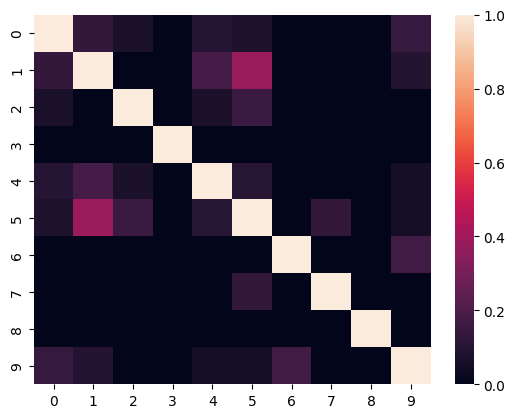

In [54]:
cosine_matrix = np.zeros((10, 10))
vectors = CountVectorizer().fit_transform([t for t in text[10:20]])

for i in range(10):
    for j in range(10):
        cosine_matrix[i][j] = cosine_similarity(vectors[i], vectors[j])[0, 0]
        
document = Document()
save_picture_in_document(cosine_matrix, document)
document.save('data/pictures_1.docx')

## Тестирование программ на Питоне

У Питона есть две встроенные возможности для проверки корректности выполнения программы. Первая из них - это оператор assert. Он проверяет истинность переданного выражения, и если оно ложно, останавливает выполнение программы.

In [55]:
assert 2==3, "That is the question"

AssertionError: That is the question

Однако такие проверки скорее походят на проверку корректного состояния программы, чем на тестирование. Тесты для тестирования пишутся и выполняются отдельно. В соответствии с методологией Agile, сперва пишутся тесты, а только потом код, который проверяется этими тестами.

Простейшим видом тестов являются модульные тесты, которые проверяют работу отдельных функций и модулей. Более сложными являются интеграционные тесты, проверяющие корректность взаимодействия модулей между собой. Здесь мы разберем инструментарий для модульного тестирования, однако в него могут быть внесены и интеграционные тесты.

#### Библиотека unittest

[Документация на unittest](https://docs.python.org/3/library/unittest.html).

Альтернатива - [doctest](https://docs.python.org/3/library/doctest.html#module-doctest), для которого тесты пишутся в строках документации к функциям. Но всё, что он может, это тестировать функции.

In [56]:
import unittest
# Just for fun.
from abc import abstractmethod
# Need for an example.
import sys

Тесты пишутся обязательно как класс, наследуемый от `unittest.TestCase`. Каждая функция этого класса будет отдельным тестом, все вместе они составят набор тестов.

Для вычисления результатов тестов используются функции, описанные в [документации](https://docs.python.org/3/library/unittest.html). В примере ниже используется простейшая - `assertEqual`.


|Method|Checks that|
|:-----------|:-------------|
|assertEqual(a, b)|a == b|
|assertNotEqual(a, b)|a != b|
|assertTrue(x)|bool(x) is True|
|assertFalse(x)|bool(x) is False|
|assertIs(a, b)|a is b|
|assertIsNot(a, b)|a is not b|
|assertIsNone(x)|x is None|
|assertIsNotNone(x)|x is not None|
|assertIn(a, b)|a in b|
|assertNotIn(a, b)|a not in b|
|assertIsInstance(a, b)|isinstance(a, b)|
|assertNotIsInstance(a, b)|not isinstance(a, b)|
|assertRaises(exc, fun, \*args, \*\*kwds)|fun(\*args, \*\*kwds) raises exc|
|assertRaisesRegex(exc, r, fun, \*args, \*\*kwds)|fun(\*args, \*\*kwds) raises exc and the message matches regex r|
|assertWarns(warn, fun, \*args, \*\*kwds)|fun(\*args, \*\*kwds) raises warn|
|assertWarnsRegex(warn, r, fun, \*args, \*\*kwds)|fun(\*args, \*\*kwds) raises warn and the message matches regex r|
|assertLogs(logger, level)|The with block logs on logger with minimum level|

In [57]:
class TestNotebook(unittest.TestCase):
    
    def test_add(self):
        a = 2 + 2
        self.assertEqual(a, 4)
        
    def test_mul(self):
        self.assertEqual(2*2, 4)


Вот так, увы, не работает. 

In [58]:
unittest.main()

E
ERROR: /home/edward/ (unittest.loader._FailedTest./home/edward/)
----------------------------------------------------------------------
AttributeError: module '__main__' has no attribute '/home/edward/'

----------------------------------------------------------------------
Ran 1 test in 0.001s

FAILED (errors=1)


SystemExit: 1

/home/edward/.local/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


Чтобы заработало, надо использовать некоторое волшебство.

In [59]:
unittest.main(argv=[''], verbosity=2, exit=False)

test_add (__main__.TestNotebook.test_add) ... ok
test_mul (__main__.TestNotebook.test_mul) ... ok

----------------------------------------------------------------------
Ran 2 tests in 0.002s

OK


Тесты должны быть оформлены в виде функций, имя которых начинается с `test`, все остальные функции считаются сервисными.

In [60]:
class TestNotebook2(unittest.TestCase):
    
    def add2(self):
        self.assertEqual(2+2, 4)
        
    def mul2(self):
        self.assertEqual(2*2, 6)        

In [61]:
unittest.main(argv=[''], verbosity=2, exit=False)

test_add (__main__.TestNotebook.test_add) ... ok
test_mul (__main__.TestNotebook.test_mul) ... ok

----------------------------------------------------------------------
Ran 2 tests in 0.002s

OK


Если создаются несколько классов, наследуемых от TestCase, они будут использованы все в порядке объявления.

In [62]:
class TestNotebook2(unittest.TestCase):
    
    def anyOther(self):
        some_code = 42
    
    def testAdd2(self):
        self.assertEqual(2+2, 4)
        
    def testMul2(self):
        self.assertEqual(2*2, 6)


In [63]:
unittest.main(argv=[''], verbosity=2, exit=False)

test_add (__main__.TestNotebook.test_add) ... ok
test_mul (__main__.TestNotebook.test_mul) ... ok
testAdd2 (__main__.TestNotebook2.testAdd2) ... ok
testMul2 (__main__.TestNotebook2.testMul2) ... FAIL

FAIL: testMul2 (__main__.TestNotebook2.testMul2)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/tmp/ipykernel_92847/3904879068.py", line 10, in testMul2
    self.assertEqual(2*2, 6)
    ~~~~~~~~~~~~~~~~^^^^^^^^
AssertionError: 4 != 6

----------------------------------------------------------------------
Ran 4 tests in 0.003s

FAILED (failures=1)


In [64]:
class TestNotebook3(unittest.TestCase):
    
    def testadd3(self):
        self.assertTrue(2+2==4)
        
    def testmul3(self):
        self.assertFalse(2*2==6)


In [65]:
unittest.main(argv=[''], verbosity=2, exit=False)

test_add (__main__.TestNotebook.test_add) ... ok
test_mul (__main__.TestNotebook.test_mul) ... ok
testAdd2 (__main__.TestNotebook2.testAdd2) ... ok
testMul2 (__main__.TestNotebook2.testMul2) ... FAIL
testadd3 (__main__.TestNotebook3.testadd3) ... ok
testmul3 (__main__.TestNotebook3.testmul3) ... ok

FAIL: testMul2 (__main__.TestNotebook2.testMul2)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/tmp/ipykernel_92847/3904879068.py", line 10, in testMul2
    self.assertEqual(2*2, 6)
    ~~~~~~~~~~~~~~~~^^^^^^^^
AssertionError: 4 != 6

----------------------------------------------------------------------
Ran 6 tests in 0.005s

FAILED (failures=1)


Опробуем некоторый пример, чуть более похожий на настоящий. Напишем класс, который будет формировать некоторое выражение в прямой польской записи.  
Базовый класс `Clause` будет хранить строку выражения и некий глобальный идентификатор, считающий выражения. Класс будет абстрактным.  
Класс `WordClause` будет хранить одно слово из выражения.  
Класс `ComplexClause` будет хранить список потомков и формировать из себя и них польскую запись.


In [66]:
class Clause:
    stringRepr = ''
    globalId = 0
    
    def __init__(self, _srepr):
        self.stringRepr = _srepr
        self.id = Clause.globalId + 1
        Clause.globalId += 1
    
    @abstractmethod
    def getStringRepr(self):
        pass
    

class WordClause(Clause):
    def getStringRepr(self):
        return self.stringRepr
    
class ComplexClause(Clause):
    def __init__(self, _srepr):
        Clause.__init__(self, _srepr)
        self.childs = []
    
    def getStringRepr(self):
        tstr = self.stringRepr + '['
        for c in self.childs:
            tstr += c.getStringRepr() + ','
        if len(self.childs) != 0:
            tstr = tstr[:-1]
        tstr += ']'
        return tstr
    
    def addClause(self, cla):
        self.childs.append(cla)

Протестируем корректность формирования таких выражений.

In [67]:
class ClauseTest(unittest.TestCase):
    # Функция с волшебным именем для инициализации переменных перед выполнением набора тестов.
    def setUp(self):
        print("setting up an object")
        self.cl1 = WordClause('123')
        self.cl2 = WordClause('234')
        self.cl3 = WordClause('345')
        self.cl4 = WordClause('456')
        self.ccl1 = ComplexClause('qwe')
        self.ccl2 = ComplexClause('asd')
        self.ccl3 = ComplexClause('zxc')

    # Функция с волшебным именем для инициализации класса.
    @classmethod
    def setUpClass(cls):
        print("setting up the class")
    
    # Функция с волшебным именем для очистки данных после успешного завершения тестов.
    def tearDown(self):
        print("tearing down")
        
    # Функция с волшебным именем для очистки данных в любом случае.
    def doCleanups(self):
        '''
    If setUp() fails, meaning that tearDown() is not called, then any cleanup functions added will still be called.
    addCleanup(function, /, *args, **kwargs)

    Add a function to be called after tearDown() to cleanup resources used during the test. Functions will be called in reverse order to the order they are added (LIFO). They are called with any arguments and keyword arguments passed into addCleanup() when they are added.
        '''
        print("cleaning up")

#     def shortDescription(self):
#         return "This is a testcase for word clauses."

    def testComplesClauseAddTest(self):
        '''test name in docstring'''
        print("start testing process 1")
        self.ccl1.addClause(self.cl1)
        self.assertEqual(len(self.ccl1.childs), 1)
        self.ccl1.addClause(self.cl2)
        self.assertEqual(len(self.ccl1.childs), 2)
        self.ccl2.addClause(self.cl3)
        self.ccl2.addClause(self.cl4)
        self.ccl3.addClause(self.ccl1)
        self.assertEqual(len(self.ccl3.childs), 1)
        self.ccl3.addClause(self.ccl2)
        self.assertEqual(len(self.ccl3.childs), 2)
        print("finish testing process 1")
        
    def testWordClauseStringReprTest(self):
        print("start testing process 2")
        self.assertEqual(self.cl1.getStringRepr(), '123')
        self.assertEqual(self.cl2.getStringRepr(), '234')
        self.assertEqual(self.ccl3.getStringRepr(), 'zxc[qwe[123,234],asd[345,456]]')
        print("finish testing process 2")
        # with self.subTest(i=i): - позволит проолжить тест.

    def testWordClauseStringReprTest2(self):
        print("start testing process 3")
        self.ccl1.addClause(self.cl1)
        self.ccl1.addClause(self.cl2)
        self.ccl2.addClause(self.cl3)
        self.ccl2.addClause(self.cl4)
        self.ccl3.addClause(self.ccl1)
        self.ccl3.addClause(self.ccl2)
        self.assertEqual(self.ccl3.getStringRepr(), 'zxc[qwe[123,234],asd[345,456]]')
        print("finish testing process 3")


In [68]:
unittest.main(argv=[''], verbosity=2, exit=False)

testComplesClauseAddTest (__main__.ClauseTest.testComplesClauseAddTest)
test name in docstring ... ok
testWordClauseStringReprTest (__main__.ClauseTest.testWordClauseStringReprTest) ... FAIL
testWordClauseStringReprTest2 (__main__.ClauseTest.testWordClauseStringReprTest2) ... ok
test_add (__main__.TestNotebook.test_add) ... ok
test_mul (__main__.TestNotebook.test_mul) ... ok
testAdd2 (__main__.TestNotebook2.testAdd2) ... ok
testMul2 (__main__.TestNotebook2.testMul2) ... FAIL
testadd3 (__main__.TestNotebook3.testadd3) ... ok
testmul3 (__main__.TestNotebook3.testmul3) ... ok

FAIL: testWordClauseStringReprTest (__main__.ClauseTest.testWordClauseStringReprTest)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/tmp/ipykernel_92847/1346343597.py", line 54, in testWordClauseStringReprTest
    self.assertEqual(self.ccl3.getStringRepr(), 'zxc[qwe[123,234],asd[345,456]]')
    ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

setting up the class
setting up an object
start testing process 1
finish testing process 1
tearing down
cleaning up
setting up an object
start testing process 2
tearing down
cleaning up
setting up an object
start testing process 3
finish testing process 3
tearing down
cleaning up


In [69]:
def external_resource_available():
    return False

class TestSkipTest(unittest.TestCase):
    @unittest.skip("demonstrating skipping")
    def test_nothing(self):
        self.fail("shouldn't happen")

    @unittest.skipIf(not sys.platform.startswith("win"), "requires Windows")
    def test_format(self):
        # Tests that work for only a certain version of the library.
        pass

    @unittest.skipUnless(sys.platform.startswith("win"), "requires Windows")
    def test_windows_support(self):
        # windows specific testing code
        pass

    def test_maybe_skipped(self):
        if not external_resource_available():
            self.skipTest("external resource not available")
        # test code that depends on the external resource
        pass
    
    

# @unittest.expectedFailure
# Mark the test as an expected failure or error. 
# If the test fails or errors it will be considered a success. 
# If the test passes, it will be considered a failure.


In [70]:
unittest.main(argv=[''], verbosity=2, exit=False)

testComplesClauseAddTest (__main__.ClauseTest.testComplesClauseAddTest)
test name in docstring ... ok
testWordClauseStringReprTest (__main__.ClauseTest.testWordClauseStringReprTest) ... FAIL
testWordClauseStringReprTest2 (__main__.ClauseTest.testWordClauseStringReprTest2) ... ok
test_add (__main__.TestNotebook.test_add) ... ok
test_mul (__main__.TestNotebook.test_mul) ... ok
testAdd2 (__main__.TestNotebook2.testAdd2) ... ok
testMul2 (__main__.TestNotebook2.testMul2) ... FAIL
testadd3 (__main__.TestNotebook3.testadd3) ... ok
testmul3 (__main__.TestNotebook3.testmul3) ... ok
test_format (__main__.TestSkipTest.test_format) ... skipped 'requires Windows'
test_maybe_skipped (__main__.TestSkipTest.test_maybe_skipped) ... skipped 'external resource not available'
test_nothing (__main__.TestSkipTest.test_nothing) ... skipped 'demonstrating skipping'
test_windows_support (__main__.TestSkipTest.test_windows_support) ... skipped 'requires Windows'

FAIL: testWordClauseStringReprTest (__main__.Cla

setting up the class
setting up an object
start testing process 1
finish testing process 1
tearing down
cleaning up
setting up an object
start testing process 2
tearing down
cleaning up
setting up an object
start testing process 3
finish testing process 3
tearing down
cleaning up


Можно снизить уровень "надоедливости" вывода результатов тестов.

In [71]:
unittest.main(argv=[''], verbosity=1, exit=False)

.F....F..ssss
FAIL: testWordClauseStringReprTest (__main__.ClauseTest.testWordClauseStringReprTest)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/tmp/ipykernel_92847/1346343597.py", line 54, in testWordClauseStringReprTest
    self.assertEqual(self.ccl3.getStringRepr(), 'zxc[qwe[123,234],asd[345,456]]')
    ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: 'zxc[]' != 'zxc[qwe[123,234],asd[345,456]]'
- zxc[]
+ zxc[qwe[123,234],asd[345,456]]


FAIL: testMul2 (__main__.TestNotebook2.testMul2)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/tmp/ipykernel_92847/3904879068.py", line 10, in testMul2
    self.assertEqual(2*2, 6)
    ~~~~~~~~~~~~~~~~^^^^^^^^
AssertionError: 4 != 6

----------------------------------------------------------------------
Ran 13 tests in 0.005s

FAILED (failures=2, skipped=4)


setting up the class
setting up an object
start testing process 1
finish testing process 1
tearing down
cleaning up
setting up an object
start testing process 2
tearing down
cleaning up
setting up an object
start testing process 3
finish testing process 3
tearing down
cleaning up
